In [10]:
import torch
from torch import nn
from torchvision import models
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import ImageFolder

torch.manual_seed(42)

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = ImageFolder(
    "../data/train",
    transform=train_transforms
)

val_dataset = ImageFolder(
    "../data/val",
    transform=val_transforms
)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Device: {device}")

Device: cuda


In [11]:
train_dataloader = DataLoader(
    dataset=train_dataset,
    batch_size=64,
    shuffle=True
)

val_dataloader = DataLoader(
    dataset=val_dataset,
    batch_size=64,
    shuffle=False
)

images, labels = next(iter(train_dataloader))

print(images.shape)
print(labels.shape)
print(images.min())
print(images.max())

torch.Size([64, 3, 224, 224])
torch.Size([64])
tensor(-1.7925)
tensor(2.6400)


In [12]:
model = models.resnet18(weights="DEFAULT")

model.fc = nn.Linear(model.fc.in_features, 10)

# Freeze Backbone
for param in model.parameters():
    param.requires_grad = False

# Unfreeze Classifier
for param in model.fc.parameters():
    param.requires_grad = True

model = model.to(device)

print(model.fc)

Linear(in_features=512, out_features=10, bias=True)


In [13]:
from torchmetrics.classification import (
    MulticlassAccuracy,
    MulticlassPrecision,
    MulticlassRecall
)
from torch.optim import Adam

train_acc_metric = MulticlassAccuracy(num_classes=10).to(device)
train_prec_metric = MulticlassPrecision(num_classes=10, average="macro").to(device)
train_rec_metric = MulticlassRecall(num_classes=10, average="macro").to(device)

val_acc_metric = MulticlassAccuracy(num_classes=10).to(device)
val_prec_metric = MulticlassPrecision(num_classes=10, average="macro").to(device)
val_rec_metric = MulticlassRecall(num_classes=10, average="macro").to(device)


loss_fn = nn.CrossEntropyLoss()
optimizer = Adam(params=filter(lambda p: p.requires_grad, model.parameters()), lr=0.0005, weight_decay=1e-4)

In [14]:
import pandas as pd

results = []
epochs = 30

best_val_acc = 0

for epoch in range(epochs):
    history = {}
    train_running_loss = 0

    history["epoch"] = epoch + 1

    # Training Loop
    model.train()
    for images, labels in train_dataloader:
        images, labels = images.to(device), labels.to(device)

        output = model(images)

        loss = loss_fn(output, labels)
        train_running_loss += loss.item()

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_acc_metric.update(output, labels)
        train_prec_metric.update(output, labels)
        train_rec_metric.update(output, labels)

    train_loss = train_running_loss / len(train_dataloader)

    history["train_loss"] = train_loss
    history["train_acc"] = train_acc_metric.compute().item()
    history["train_prec"] = train_prec_metric.compute().item()
    history["train_rec"] = train_rec_metric.compute().item()

    train_acc_metric.reset()
    train_prec_metric.reset()
    train_rec_metric.reset()


    # Validation Loop
    model.eval()

    val_running_loss = 0

    with torch.inference_mode():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)

            output = model(images)

            loss = loss_fn(output, labels)
            val_running_loss += loss.item()

            val_acc_metric.update(output, labels)
            val_prec_metric.update(output, labels)
            val_rec_metric.update(output, labels)

        val_loss = val_running_loss / len(val_dataloader)

        history["val_loss"] = val_loss
        history["val_acc"] = val_acc_metric.compute().item()
        history["val_prec"] = val_prec_metric.compute().item()
        history["val_rec"] = val_rec_metric.compute().item()
    
        val_acc_metric.reset()
        val_prec_metric.reset()
        val_rec_metric.reset()

    print(f"Epoch {epoch + 1} :-")
    print(f"Train Loss: {history['train_loss']:.2f} | Train Acc: {history['train_acc']*100:.2f}% | Train Prec: {history['train_prec']*100:.2f}% | Train Rec: {history['train_rec']*100:.2f}%")
    print(f"Val Loss: {history['val_loss']:.2f} | Val Acc: {history['val_acc']*100:.2f}% | Val Prec: {history['val_prec']*100:.2f}% | Val Rec: {history['val_rec']*100:.2f}%")

    if(history['val_acc'] >= best_val_acc):
        best_val_acc = history['val_acc']
        torch.save(model.state_dict(), "../models/TL_Frozen_Backbone.pt")
        print(f"Best Model Saved!! Val Acc: {history['val_acc']*100:.2f}%")
    print("\n")
    results.append(history)

df = pd.DataFrame(results)

Epoch 1 :-
Train Loss: 0.83 | Train Acc: 77.06% | Train Prec: 77.34% | Train Rec: 77.06%
Val Loss: 0.42 | Val Acc: 88.53% | Val Prec: 88.53% | Val Rec: 88.53%
Best Model Saved!! Val Acc: 88.53%


Epoch 2 :-
Train Loss: 0.40 | Train Acc: 88.02% | Train Prec: 88.05% | Train Rec: 88.02%
Val Loss: 0.31 | Val Acc: 90.41% | Val Prec: 90.65% | Val Rec: 90.41%
Best Model Saved!! Val Acc: 90.41%


Epoch 3 :-
Train Loss: 0.32 | Train Acc: 89.76% | Train Prec: 89.80% | Train Rec: 89.76%
Val Loss: 0.26 | Val Acc: 91.68% | Val Prec: 92.08% | Val Rec: 91.68%
Best Model Saved!! Val Acc: 91.68%


Epoch 4 :-
Train Loss: 0.29 | Train Acc: 90.36% | Train Prec: 90.43% | Train Rec: 90.36%
Val Loss: 0.24 | Val Acc: 92.66% | Val Prec: 92.74% | Val Rec: 92.66%
Best Model Saved!! Val Acc: 92.66%


Epoch 5 :-
Train Loss: 0.27 | Train Acc: 91.25% | Train Prec: 91.28% | Train Rec: 91.25%
Val Loss: 0.24 | Val Acc: 91.66% | Val Prec: 92.25% | Val Rec: 91.66%


Epoch 6 :-
Train Loss: 0.25 | Train Acc: 91.37% | Train

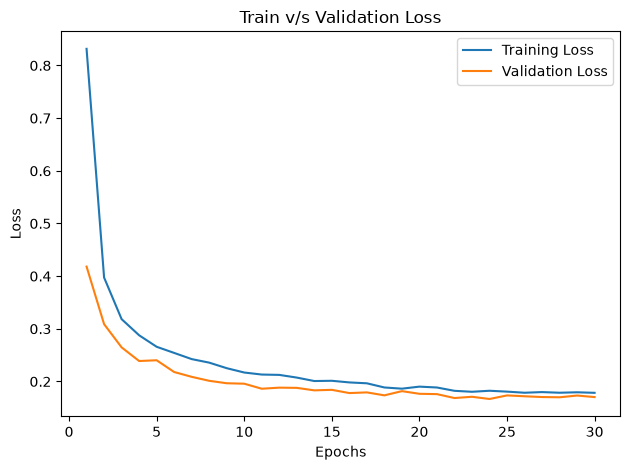

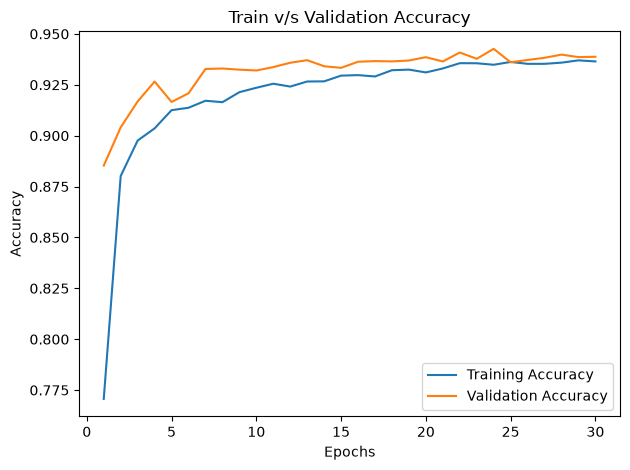

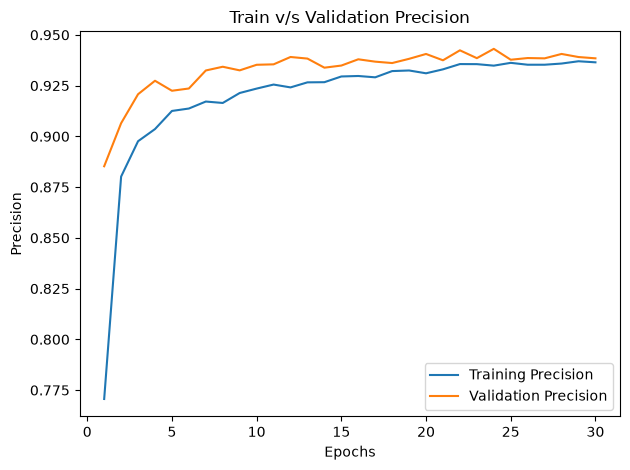

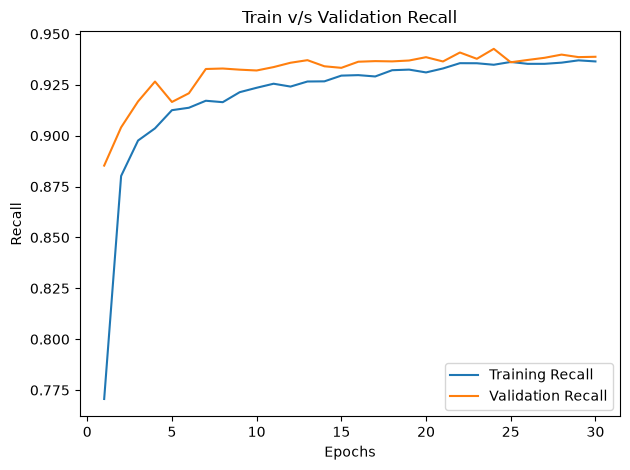

In [16]:
import matplotlib.pyplot as plt

def plot_metric(x, y1, y2, metric):
    xlabel = df[x]
    y1label = df[y1]
    y2label = df[y2]

    plt.title(f"Train v/s Validation {metric}")

    plt.plot(xlabel, y1label, label=f"Training {metric}")
    plt.plot(xlabel, y2label, label=f"Validation {metric}")

    plt.xlabel("Epochs")
    plt.ylabel(f"{metric}")

    plt.legend()
    plt.tight_layout()
    plt.show()


plot_metric('epoch', 'train_loss', 'val_loss', 'Loss')
plot_metric('epoch', 'train_acc', 'val_acc', 'Accuracy')
plot_metric('epoch', 'train_rec', 'val_prec', 'Precision')
plot_metric('epoch', 'train_rec', 'val_rec', 'Recall')